# 03 · State vector and equations of motion

How the simulator moves the aircraft: what it remembers from one step to the next (the state), the equations that change it, the inertia that resists rotation, the fan spool lag, and the integrator that steps it all forward 1000 times a second.

In [1]:
# Setup: make the repository importable and load the V3 airframe used throughout these notebooks
import sys, math, pathlib
ROOT = pathlib.Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt
from airframe_designer.geometry.airframe import Airframe

np.set_printoptions(precision=4, suppress=True)
plt.rcParams.update({"figure.figsize": (7, 3.6), "axes.grid": True, "grid.alpha": 0.3})

AF_PATH = ROOT / "airframes" / "atlas_v3_v34_foils_50_65_50_tuned.json"
af = Airframe.load(AF_PATH)
af.resolve_mass()
G = 9.80665
print(f"{af.name}: {af.mass.mass:.2f} kg, {len(af.active_rotors())} fans, hover pitch {af.hover_pitch_deg} deg, parked {af.landed_pitch_deg} deg")

ATLAS_V3_V34_FOILS_50_65_50_TUNED: 11.83 kg, 9 fans, hover pitch 23.85 deg, parked 23.85 deg


In [2]:
from airframe_designer.dynamics.rigid_body import RigidBody
from airframe_designer.dynamics.quaternion import q_to_euler
rb = RigidBody(af)

## 1. The state vector

**Theory.** For V3 the state is

$$\mathbf x = \big[\ \mathbf p^N\ (3)\ \ \mathbf v^N\ (3)\ \ \mathbf q\ (4)\ \ \boldsymbol\omega^B\ (3)\ \ \bar\Omega_1\dots\bar\Omega_9\ (9)\ \big],\qquad 22\ \text{numbers},\ 21\ \text{degrees of freedom}.$$

> **Note: state versus everything else**
>
> A state is a quantity that needs its own history: next step's velocity is this step's velocity plus the acceleration. Everything else (leg forces, the accelerometer reading, total thrust) is recomputed from the state every step. The quaternion has 4 numbers but only 3 degrees of freedom, because of the unit-length constraint.

In [3]:
state = {"p (NED, m)": rb.pos, "v (NED, m/s)": rb.vel, "q (body->NED)": rb.q, "omega (body, rad/s)": rb.rates,
         "fan speeds (0..1)": rb.omega}
n = 0
for k, v in state.items():
    n += len(v); print(f"{k:22s} {len(v):2d}  {np.round(v, 4)}")
print("total state length:", n)
print("parked pitch from q:", round(math.degrees(q_to_euler(rb.q)[1]), 2), "deg;  CG height:", round(-rb.pos[2], 3), "m")

p (NED, m)              3  [ 0.      0.     -0.3463]
v (NED, m/s)            3  [0. 0. 0.]
q (body->NED)           4  [0.9784 0.     0.2066 0.    ]
omega (body, rad/s)     3  [0. 0. 0.]
fan speeds (0..1)       9  [0. 0. 0. 0. 0. 0. 0. 0. 0.]
total state length: 22
parked pitch from q: 23.85 deg;  CG height: 0.346 m


## 2. Equations of motion

**Theory.**

$$\begin{aligned}
\dot{\mathbf p}^N &= \mathbf v^N\\
m\,\dot{\mathbf v}^N &= R(\mathbf q)\,\mathbf F^B + m g\,\hat{\mathbf e}_3 + \mathbf F^N_{\text{contact}}\\
\dot{\mathbf q} &= \tfrac12\,\mathbf q\otimes[0,\ \boldsymbol\omega^B]\\
I\,\dot{\boldsymbol\omega}^B &= \mathbf M^B - \boldsymbol\omega^B\times I\boldsymbol\omega^B\\
\dot{\bar\Omega}_i &= (u_i - \bar\Omega_i)/\tau_i
\end{aligned}$$

with $\hat{\mathbf e}_3 = (0, 0, 1)$ pointing down. The fourth line is Euler's equation for a rigid body.

> **Note: "translation is written in NED, rotation in the body frame"**
>
> Writing an equation in a frame means choosing which axes list the components of its arrows. **Translation** (how the CG moves) is written in NED, because there Newton's law has its plain form, gravity is the same everywhere, and the floor is simply z = 0. **Rotation** (how the body spins) is written in body axes, because every part is bolted to the airframe, so the inertia tensor is a fixed set of numbers there; in NED it would change every time the aircraft turns, $I^N = R\,I^B R^{\mathsf T}$. The price is the extra $\boldsymbol\omega\times I\boldsymbol\omega$ term. The two halves are joined by $R(\mathbf q)$: forces are computed in body axes, where the fans are, and turned into NED.

## 3. The inertia tensor and the parallel-axis theorem

**Theory.** For each part $k$ with own inertia $I_k$ about its own centre, mass $m_k$ and position $\mathbf r_k$ from the CG,

$$I = \sum_k \Big(I_k + m_k\big(\lVert\mathbf r_k\rVert^2 E - \mathbf r_k\mathbf r_k^{\mathsf T}\big)\Big),\qquad \text{scalar form: } I = I_{\text{own}} + m d^2 .$$

The off-diagonal entries are the products of inertia, $I_{xz} = \sum m_k x_k z_k$ and so on (with the minus sign convention in the tensor).

In [4]:
I = af.mass.tensor()
print("V3 inertia tensor about the CG (kg m^2), structural axes:\n", I)
vals, vecs = np.linalg.eigh(I)
print("principal moments:", np.round(vals, 4))
print("principal axes (columns):\n", np.round(vecs, 3))

V3 inertia tensor about the CG (kg m^2), structural axes:
 [[ 0.5695 -0.0061  0.0841]
 [-0.0061  0.925   0.0002]
 [ 0.0841  0.0002  1.308 ]]
principal moments: [0.5599 0.9251 1.3175]
principal axes (columns):
 [[ 0.994  0.017 -0.112]
 [ 0.017 -1.     0.001]
 [-0.112 -0.003 -0.994]]


> **Note: parallel-axis theorem with one battery**
>
> Inertia depends on how far mass sits from the axis, squared. Each part has a small inertia about its own centre; moving it a distance $d$ away adds $m d^2$. The next cell does this for one of V3's six batteries (0.77 kg, about 15 × 5 cm) placed 0.25 m ahead of the CG: its own pitch inertia is tiny, the parallel-axis part is about 30 times bigger, and that single battery adds about 5 % to the whole aircraft's pitch inertia. That is why moving batteries changes how quickly ATLAS can pitch and yaw.

In [5]:
m_b, Lx, Lz, d = 0.77, 0.15, 0.05, 0.25
own = m_b * (Lx**2 + Lz**2) / 12
shift = m_b * d**2
print(f"own pitch inertia {own:.4f}, parallel-axis term {shift:.4f} ({shift / own:.0f}x), "
      f"share of the aircraft's Iyy {100 * (own + shift) / I[1, 1]:.1f} %")

# The same with the code's own routine, for two point masses
from airframe_designer.geometry.mass import MassProperties, MassItem
mp = MassProperties(from_items=True, items=[MassItem("battery", m_b, [d, 0, 0], [m_b * Lz**2 / 12, own, m_b * Lx**2 / 12]),
                                             MassItem("rest", 11.0, [-d * m_b / 11.0, 0, 0])]).resolve()
print("MassProperties.resolve: cg", mp.cg, " inertia", mp.inertia)

own pitch inertia 0.0016, parallel-axis term 0.0481 (30x), share of the aircraft's Iyy 5.4 %
MassProperties.resolve: cg [0.0, 0.0, 0.0]  inertia [0.00016, 0.053098, 0.052938]


## 4. Euler's equation in action: the intermediate-axis instability

**Theory.** With no moments, $I\dot{\boldsymbol\omega} = -\boldsymbol\omega\times I\boldsymbol\omega$. Spin about the axis with the smallest or largest principal moment is stable; spin about the middle one is not. This is the gyroscopic term doing its work.

> **Note: why this matters for a drone**
>
> The $\boldsymbol\omega\times I\boldsymbol\omega$ term couples the axes: spinning about one axis creates angular acceleration about the others. At ATLAS's normal rates it is small, but it is why roll, pitch and yaw are not fully independent, and why the products of inertia (here $I_{xz}$) matter for the mixer and the gains. The cell spins the V3 inertia about its middle principal axis with a tiny disturbance.

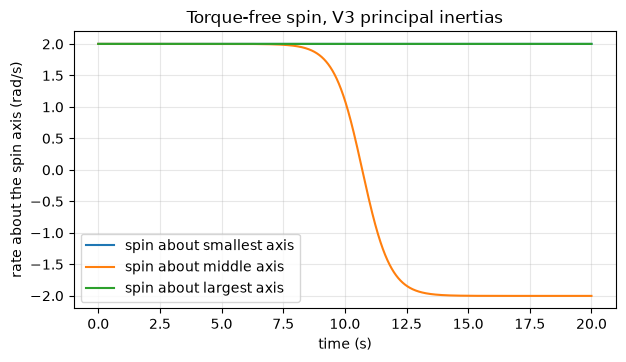

In [6]:
Ip = np.diag(vals); Ip_inv = np.linalg.inv(Ip)
dt, T = 1e-3, 20.0
for axis, label in ((0, "smallest"), (1, "middle"), (2, "largest")):
    w = np.zeros(3); w[axis] = 2.0; w += 1e-3       # 2 rad/s plus a small disturbance
    hist = []
    for _ in range(int(T / dt)):
        w = w + Ip_inv @ (-np.cross(w, Ip @ w)) * dt
        hist.append(w.copy())
    hist = np.array(hist)
    plt.plot(np.arange(len(hist)) * dt, hist[:, axis], label=f"spin about {label} axis")
plt.xlabel("time (s)"); plt.ylabel("rate about the spin axis (rad/s)"); plt.legend(); plt.title("Torque-free spin, V3 principal inertias")
plt.show()

## 5. Fan spool lag: first order with $\tau = 0.12$ s

**Theory.** $\dot{\bar\Omega} = (u - \bar\Omega)/\tau$, whose step response is $\bar\Omega(t) = u + (\bar\Omega_0 - u)\,e^{-t/\tau}$. Thrust is $T = T_{\text{eff}}\,\bar\Omega^2$. `RotorSet.spool` implements the first line with separate spin-up and spin-down constants.

> **Note: what spool and lag mean**
>
> "Spool" is jet-engine language for the fan's rotational speed. A fan cannot change speed instantly, because its rotor has inertia and the motor's current is limited. The first-order model says: the speed moves towards the command at a rate proportional to the remaining gap. After one time constant τ it has done 63 % of the change, after three 95 %. Because thrust goes with speed squared, thrust lags even more at first. The 0.12 s value is a default for ducted fans and has not been measured on the ATLAS fans.

tau (s): [0.12 0.12 0.12 0.12 0.12 0.12 0.12 0.12 0.12]  tau_down (s): [0.12 0.12 0.12 0.12 0.12 0.12 0.12 0.12 0.12]


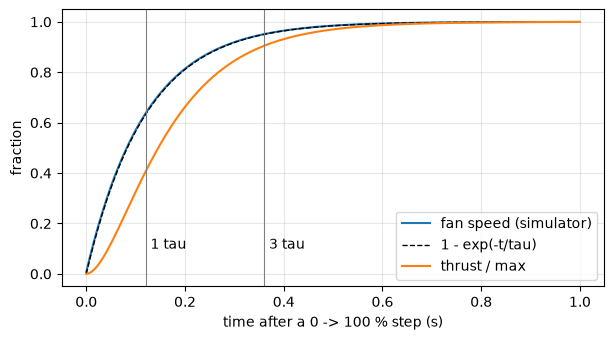

phase lag of the fans for a 2.0 Hz wobble: 56 deg


In [7]:
rs = rb.rotors
print("tau (s):", rs.tau, " tau_down (s):", rs.tau_down)
dt, T = 1e-3, 1.0
omega = np.zeros(rs.n); cmd = np.full(rs.n, 1.0); t = np.arange(0, T, dt); speed, thrust = [], []
for _ in t:
    omega = rs.spool(omega, cmd, dt)
    speed.append(omega[0]); thrust.append(rs.thrust(omega)[0] / rs.tmax[0])
tau = rs.tau[0]
plt.plot(t, speed, label="fan speed (simulator)")
plt.plot(t, 1 - np.exp(-t / tau), "k--", lw=1, label="1 - exp(-t/tau)")
plt.plot(t, thrust, label="thrust / max")
for k in (1, 3):
    plt.axvline(k * tau, color="gray", lw=0.8); plt.text(k * tau + 0.01, 0.1, f"{k} tau")
plt.xlabel("time after a 0 -> 100 % step (s)"); plt.ylabel("fraction"); plt.legend(); plt.show()
f = 2.0
print(f"phase lag of the fans for a {f} Hz wobble: {math.degrees(math.atan(2 * math.pi * f * tau)):.0f} deg")

## 6. The integrator: semi-implicit Euler at 1 ms

**Theory.**

$$\mathbf v_{k+1} = \mathbf v_k + \mathbf a_k\Delta t,\quad \mathbf p_{k+1} = \mathbf p_k + \mathbf v_{k+1}\Delta t,\quad \boldsymbol\omega_{k+1} = \boldsymbol\omega_k + \dot{\boldsymbol\omega}_k\Delta t,\quad \mathbf q_{k+1} = \mathcal N\big(\mathbf q_k + \dot{\mathbf q}(\mathbf q_k, \boldsymbol\omega_{k+1})\Delta t\big).$$

Using the **new** velocity for the position (and the new rate for the attitude) is what makes it semi-implicit. For an oscillator it is stable while $\omega_n\Delta t < 2$.

> **Note: why the order of the updates matters**
>
> Take one leg as a spring: $k = 1500$ N/m on about 3.9 kg gives a natural frequency near 20 rad/s. With plain explicit Euler (old velocity for the position) every 1 ms step multiplies the bounce amplitude by $\sqrt{1 + (\omega_n\Delta t)^2}$, a tiny 0.02 %, which over one second of 1000 steps adds about 20 % of bounce out of nothing. The semi-implicit order keeps it bounded. The cell compares the two.

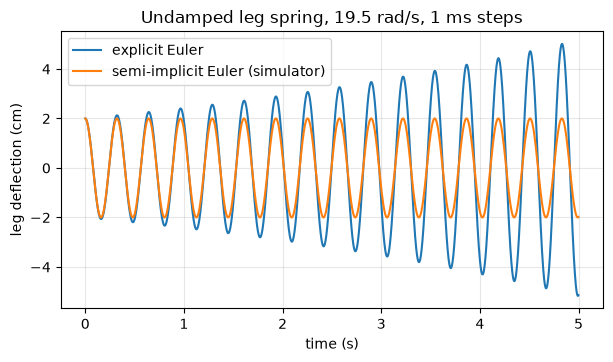

In [8]:
wn, dt, T = math.sqrt(1500 / (af.mass.mass / 3)), 1e-3, 5.0
def run(semi):
    x, v, out = 0.02, 0.0, []
    for _ in range(int(T / dt)):
        a = -wn**2 * x
        if semi:
            v = v + a * dt; x = x + v * dt
        else:
            x, v = x + v * dt, v + a * dt
        out.append(x)
    return np.array(out)
t = np.arange(int(T / dt)) * dt
plt.plot(t, run(False) * 100, label="explicit Euler")
plt.plot(t, run(True) * 100, label="semi-implicit Euler (simulator)")
plt.xlabel("time (s)"); plt.ylabel("leg deflection (cm)"); plt.legend(); plt.title(f"Undamped leg spring, {wn:.1f} rad/s, 1 ms steps"); plt.show()

## 7. The real body settling on its legs

**Theory.** Put together, `RigidBody.step(dt)` evaluates the forces, applies Newton and Euler, spools the fans and integrates. With the motors off the aircraft should settle on its legs, a little below the angle the legs were solved for (the springs compress under the weight).

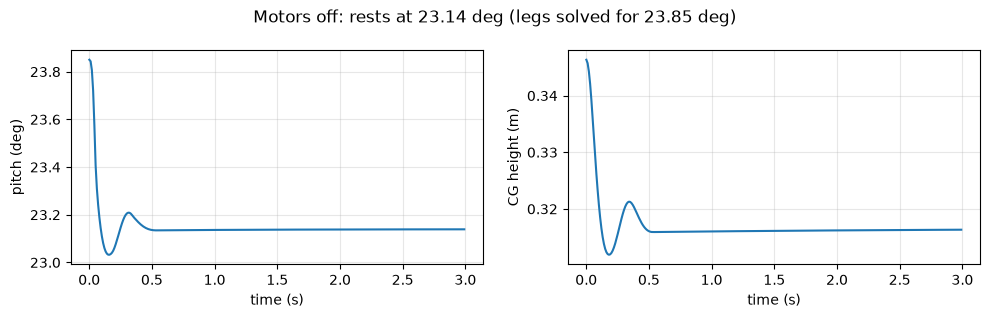

In [9]:
rb = RigidBody(af)
rb.set_motor_commands(np.zeros(rb.rotors.n))
t, pitch, height = [], [], []
for k in range(3000):
    rb.step(1e-3, detail=False)
    if k % 10 == 0:
        t.append(rb.t); pitch.append(math.degrees(q_to_euler(rb.q)[1])); height.append(-rb.pos[2])
fig, ax = plt.subplots(1, 2, figsize=(10, 3.2))
ax[0].plot(t, pitch); ax[0].set_ylabel("pitch (deg)"); ax[0].set_xlabel("time (s)")
ax[1].plot(t, height); ax[1].set_ylabel("CG height (m)"); ax[1].set_xlabel("time (s)")
plt.suptitle(f"Motors off: rests at {pitch[-1]:.2f} deg (legs solved for {af.landed_pitch_deg} deg)"); plt.tight_layout(); plt.show()